##

### HCML Project code group ScPlBuKl
Sam Busstra - 2349515  
Kasper Klink -  7423403  
Theresa Schludi - 7877854  
Jim van der Ploeg - 2548909  

In [1]:
# installs
!pip install shap
!pip install folktables
!pip install fairlearn
!pip install torch
from folktables import ACSDataSource, ACSIncome
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
!pip install folktables
!pip install fairlearn
import random
import torch


# Part 1: Exporatory data analysis
### Loading the data

In [2]:
# data loading

data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
acs_data = data_source.get_data(states=["CA", "NY", "TX"], download=True) # only take 3 states since datasize will get too big otherwise

feature_names = ACSIncome.features
df = acs_data[feature_names].copy()
df['label'] = (acs_data['PINCP'] > 50000).astype(int)

# Recode SEX to 0/1 already
df['SEX'] = df['SEX'].map({1: 0, 2: 1})  # 0=Male, 1=Female

### Descriptive statistics

In [3]:
print(df.shape)
print(df.dtypes)
print(df.describe())

(843884, 11)
AGEP       int64
COW      float64
SCHL     float64
MAR        int64
OCCP     float64
POBP       int64
RELP       int64
WKHP     float64
SEX        int64
RAC1P      int64
label      int64
dtype: object
                AGEP            COW           SCHL            MAR  \
count  843884.000000  496001.000000  818451.000000  843884.000000   
mean       40.435203       2.169490      15.983083       3.021073   
std        23.363167       1.946451       5.878467       1.867496   
min         0.000000       1.000000       1.000000       1.000000   
25%        21.000000       1.000000      14.000000       1.000000   
50%        40.000000       1.000000      18.000000       3.000000   
75%        59.000000       3.000000      21.000000       5.000000   
max        95.000000       9.000000      24.000000       5.000000   

                OCCP           POBP           RELP           WKHP  \
count  496001.000000  843884.000000  843884.000000  437311.000000   
mean     4141.377066      

### Important distributions

In [4]:

# Class imbalance in target
df['label'].value_counts(normalize=True)

# Distribution of protected attributes
df['SEX'].value_counts()
df['RAC1P'].value_counts()

# Base rates
df.groupby('SEX')['label'].mean()
df.groupby('RAC1P')['label'].mean()

# Intersectional base rates
df.groupby(['SEX', 'RAC1P'])['label'].mean().unstack()

RAC1P,1,2,3,4,5,6,7,8,9
SEX,,,,,,,,,
0,0.320121,0.177532,0.207556,0.130435,0.137019,0.319976,0.215789,0.136191,0.178239
1,0.192491,0.158275,0.132903,0.200000,0.088861,0.227896,0.124823,0.066673,0.134962


### Visualizing data

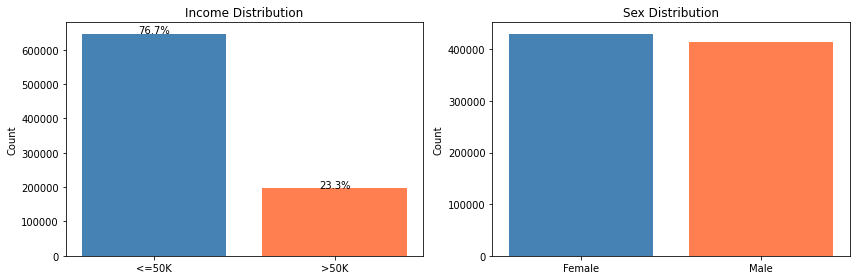

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
axes[0].bar(['<=50K', '>50K'], df['label'].value_counts().sort_index(), color=['steelblue', 'coral'])
axes[0].set_title('Income Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['label'].value_counts().sort_index()):
    axes[0].text(i, v + 100, f'{v/len(df)*100:.1f}%', ha='center')

# SEX distribution
sex_labels = {0: 'Male', 1: 'Female'}
sex_counts = df['SEX'].map(sex_labels).value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=['steelblue', 'coral'])
axes[1].set_title('Sex Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

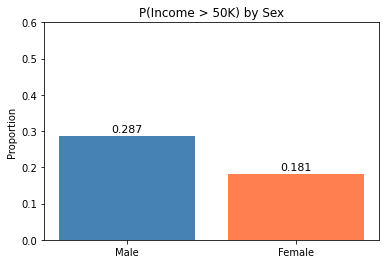

In [6]:
# Base rates by SEX
sex_base = df.groupby('SEX')['label'].mean().rename({0: 'Male', 1: 'Female'})

plt.figure(figsize=(6, 4))
bars = plt.bar(sex_base.index, sex_base.values, color=['steelblue', 'coral'])
plt.title('P(Income > 50K) by Sex')
plt.ylabel('Proportion')
plt.ylim(0, 0.6)
for bar, val in zip(bars, sex_base.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=11)
plt.show()

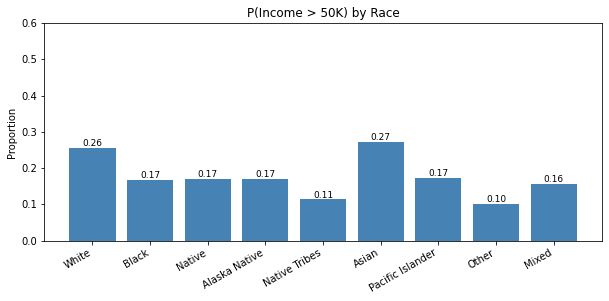

In [7]:
# Base rates by RAC1P
race_labels = {
    1: 'White', 2: 'Black', 3: 'Native', 4: 'Alaska Native',
    5: 'Native Tribes', 6: 'Asian', 7: 'Pacific Islander', 8: 'Other', 9: 'Mixed'
}
race_base = df.groupby('RAC1P')['label'].mean().rename(race_labels)

plt.figure(figsize=(10, 4))
bars = plt.bar(race_base.index, race_base.values, color='steelblue')
plt.title('P(Income > 50K) by Race')
plt.ylabel('Proportion')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 0.6)
for bar, val in zip(bars, race_base.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.2f}', ha='center', fontsize=9)
plt.show()

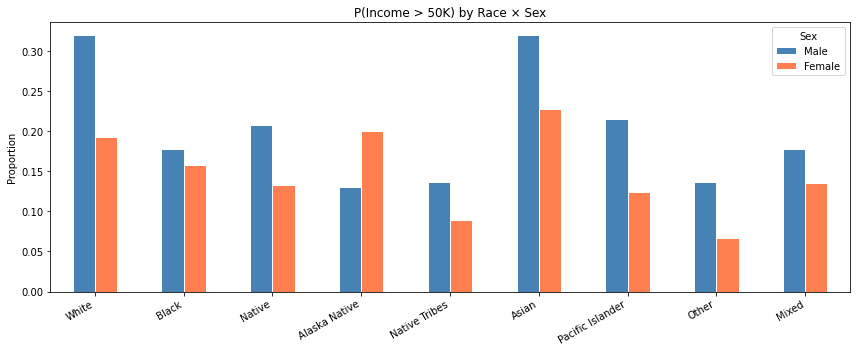

                   Male  Female  Gap (M-F)
RAC1P                                     
White             0.320   0.192      0.128
Black             0.178   0.158      0.019
Native            0.208   0.133      0.075
Alaska Native     0.130   0.200     -0.070
Native Tribes     0.137   0.089      0.048
Asian             0.320   0.228      0.092
Pacific Islander  0.216   0.125      0.091
Other             0.136   0.067      0.070
Mixed             0.178   0.135      0.043


In [8]:
# Intersectional base rates: SEX x RAC1P
intersect = df.groupby(['RAC1P', 'SEX'])['label'].mean().unstack()
intersect.index = intersect.index.map(race_labels)
intersect.columns = ['Male', 'Female']

intersect.plot(kind='bar', figsize=(12, 5), color=['steelblue', 'coral'], edgecolor='white')
plt.title('P(Income > 50K) by Race × Sex')
plt.ylabel('Proportion')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

# gap within each racial group
intersect['Gap (M-F)'] = intersect['Male'] - intersect['Female']
print(intersect.round(3))

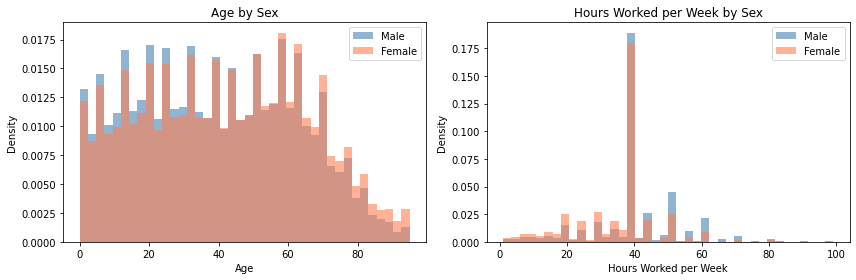

In [9]:
# Continuous feature distributions split by SEX
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes, ['AGEP', 'WKHP'], ['Age', 'Hours Worked per Week']):
    for sex, label, color in [(0, 'Male', 'steelblue'), (1, 'Female', 'coral')]:
        ax.hist(df[df['SEX'] == sex][col], bins=40, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(f'{title} by Sex')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

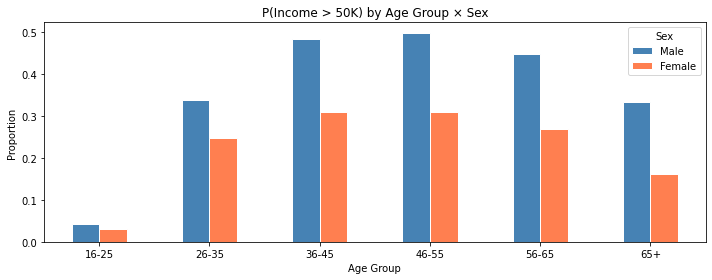

In [10]:
# Income rate by age group and sex
df['age_group'] = pd.cut(df['AGEP'], bins=[15, 25, 35, 45, 55, 65, 100],
                          labels=['16-25', '26-35', '36-45', '46-55', '56-65', '65+'])

age_sex = df.groupby(['age_group', 'SEX'])['label'].mean().unstack()
age_sex.columns = ['Male', 'Female']

age_sex.plot(kind='bar', figsize=(10, 4), color=['steelblue', 'coral'], edgecolor='white')
plt.title('P(Income > 50K) by Age Group × Sex')
plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

# Part 2: Preprocessing
### Missing values

In [11]:

# Check missing originally
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# work from copy from now on + drop nans
df_clean = df.copy()
df_clean = df_clean.dropna()
print(f"\nOriginal size: {len(df)} | After dropping NaNs: {len(df_clean)}")

Missing values per column:
AGEP              0
COW          347883
SCHL          25433
MAR               0
OCCP         347883
POBP              0
RELP              0
WKHP         406573
SEX               0
RAC1P             0
label             0
age_group    154570
dtype: int64

Total missing: 1282342

Original size: 843884 | After dropping NaNs: 437311


### Define feature groups

In [12]:
continuous_features  = ['AGEP', 'WKHP']
protected_attributes = ['SEX', 'RAC1P']   # kept separate for fairness eval
categorical_features = [col for col in df.columns
                        if col not in continuous_features + protected_attributes + ['label', 'age_group']]

print("Continuous: ", continuous_features)

print("Categorical:", categorical_features)
print("Protected:  ", protected_attributes)

Continuous:  ['AGEP', 'WKHP']
Categorical: ['COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP']
Protected:   ['SEX', 'RAC1P']


### Train test split (before encoding to avoid leakage)

In [13]:
X = df_clean.drop(columns=['label', 'age_group'], errors='ignore')
y = df_clean['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Train positive rate: {y_train.mean():.3f} | Test positive rate: {y_test.mean():.3f}")

# Save protected attributes separately for fairness evaluation later
sex_test  = X_test['SEX'].values
race_test = X_test['RAC1P'].values

Train size: 349848 | Test size: 87463
Train positive rate: 0.395 | Test positive rate: 0.395


### Build preprocessing pipeline

In [14]:
# Keep SEX and RAC1P as passthrough (not transformed)
# so we can easily include/exclude them in model configurations


preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), continuous_features),
    ('ohe',   OneHotEncoder(sparse_output = False, handle_unknown='ignore'), categorical_features),
    ('protect', 'passthrough', protected_attributes)  # keep as-is
])

# Fit on train, transform both
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Recover feature names for readability
ohe_feature_names = preprocessor.named_transformers_['ohe'].get_feature_names_out(categorical_features)
all_feature_names = continuous_features + list(ohe_feature_names) + protected_attributes

X_train_df = pd.DataFrame(X_train_proc, columns=all_feature_names)
X_test_df  = pd.DataFrame(X_test_proc,  columns=all_feature_names)


print(f"Processed feature matrix shape: {X_train_df.shape}")
print(X_train_df.head(2))

Processed feature matrix shape: (349848, 811)
       AGEP      WKHP  COW_1.0  COW_2.0  COW_3.0  COW_4.0  COW_5.0  COW_6.0  \
0 -0.054605 -0.171307      1.0      0.0      0.0      0.0      0.0      0.0   
1 -1.444200 -0.778169      1.0      0.0      0.0      0.0      0.0      0.0   

   COW_7.0  COW_8.0  ...  RELP_10  RELP_11  RELP_12  RELP_13  RELP_14  \
0      0.0      0.0  ...      0.0      1.0      0.0      0.0      0.0   
1      0.0      0.0  ...      0.0      0.0      1.0      0.0      0.0   

   RELP_15  RELP_16  RELP_17  SEX  RAC1P  
0      0.0      0.0      0.0  1.0    2.0  
1      0.0      0.0      0.0  1.0    8.0  

[2 rows x 811 columns]


# Proxy identification
### Attribute relationship analysis

In [15]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

results = []
target = "SEX"
for col in df_clean.columns:
    if col == target:
        continue
    confusion = pd.crosstab(df_clean[col], df_clean[target])
    # Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(confusion)
    # Cramér's V
    v = cramers_v(confusion)
    results.append({
        "feature": col,
        "chi2": chi2,
        "p_value": p,
        "cramers_v": v
    })

print(pd.DataFrame(results).sort_values("cramers_v", ascending=False))

      feature           chi2        p_value  cramers_v
4        OCCP  129623.463294   0.000000e+00   0.544436
7        WKHP   20327.907653   0.000000e+00   0.215601
1         COW    9579.868802   0.000000e+00   0.148008
9       label    7317.261538   0.000000e+00   0.129354
3         MAR    6064.722239   0.000000e+00   0.117763
2        SCHL    4075.559315   0.000000e+00   0.096538
6        RELP    3406.064814   0.000000e+00   0.088253
5        POBP    2548.633722   0.000000e+00   0.076341
8       RAC1P     697.136413  2.959420e-145   0.039927
0        AGEP     282.052398   6.963241e-25   0.025396
10  age_group     130.168195   2.192209e-26   0.017253


In [16]:
cramers_v_race = []
target = "RAC1P"
for col in df_clean.columns:
    if col == target:
        continue
    confusion = pd.crosstab(df_clean[col], df_clean[target])
    # Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(confusion)
    # Cramér's V
    v = cramers_v(confusion)
    cramers_v_race.append({
        "feature": col,
        "chi2": chi2,
        "p_value": p,
        "cramers_v": v
    })

print(pd.DataFrame(cramers_v_race).sort_values("cramers_v", ascending=False))

      feature           chi2        p_value  cramers_v
5        POBP  552701.180189   0.000000e+00   0.397471
9       label    9437.368480   0.000000e+00   0.146903
4        OCCP   62755.873251   0.000000e+00   0.133933
2        SCHL   35355.905689   0.000000e+00   0.100529
3         MAR    9655.968702   0.000000e+00   0.074297
6        RELP   12500.191777   0.000000e+00   0.059775
10  age_group    6823.088690   0.000000e+00   0.055861
0        AGEP    8205.297592   0.000000e+00   0.048429
7        WKHP    7209.232641   0.000000e+00   0.045395
1         COW    5322.266736   0.000000e+00   0.041697
8         SEX     697.136413  2.959420e-145   0.039927


# Models and bias mitigation
## Fairness utilities

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# get readable race name
RACE_LABELS = {1: "White", 2: "Black", 3: "Native", 4: "AlaskaNat",
               5: "AIAN", 6: "Asian", 7: "NHPI", 8: "Other", 9: "Multi"}


def confusion_rates(y_true, y_pred):
    """Confusion matrix rates for one group, returns nans where undefined"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    n             = len(y_true)
    positives     = tp + fn          # actual >50K
    negatives     = tn + fp          # actual <=50K
    predicted_pos = tp + fp
    return {
        "n":              n,
        "base_rate":      positives / n,                                  # P(y=1)
        "selection_rate": predicted_pos / n,                              # P(pred=1)
        "accuracy":       (tp + tn) / n,
        "TPR":            tp / positives if positives else np.nan,        # equal opportunity
        "FPR":            fp / negatives if negatives else np.nan,
        "PPV":            tp / predicted_pos if predicted_pos else np.nan,
        "FDR":            fp / predicted_pos if predicted_pos else np.nan,  # predictive parity
    }


def make_subgroups(sex, race, top_n_races=3):
    """Label each row "Race-Sex", keeping only the top_n_races most common races
    Rows from rarer races become NaN so they drop out """
    sex  = pd.Series(np.asarray(sex)).reset_index(drop=True)
    race = pd.Series(np.asarray(race)).reset_index(drop=True)
    top_races = race.value_counts().nlargest(top_n_races).index
    race_name = race.map(RACE_LABELS).where(race.isin(top_races))   # NaN if not top-N
    sex_name  = sex.map({0: "Male", 1: "Female"})
    return race_name + "-" + sex_name                              # NaN propagates


def intersectional_report(y_true, y_pred, sex, race, top_n_races=3, ref_group="White-Male"):
    """ One row of fairness metrics per Race-Sex subgroup, plus gaps vs ref_group"""
    groups = make_subgroups(sex, race, top_n_races)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rows = {}
    for name in groups.dropna().unique():
        mask = (groups == name).to_numpy()
        rows[name] = confusion_rates(y_true[mask], y_pred[mask])
    table = pd.DataFrame(rows).T

    ref = table.loc[ref_group]
    table["SPD"]     = table["selection_rate"] - ref["selection_rate"]   # demographic parity gap
    table["TPR_gap"] = table["TPR"]            - ref["TPR"]
    table["FPR_gap"] = table["FPR"]            - ref["FPR"]
    table["FDR_gap"] = table["FDR"]            - ref["FDR"]
    table["acc_gap"] = table["accuracy"]       - ref["accuracy"]
    return table.sort_values("selection_rate", ascending=False)


def disparity_summary(y_true, y_pred, sex, race, top_n_races=3, model_name=""):
    """Compare the demographic-parity gap on each single axis vs intersectional subgroups."""
    sex  = pd.Series(np.asarray(sex)).reset_index(drop=True)
    race = pd.Series(np.asarray(race)).reset_index(drop=True)
    pred = pd.Series(np.asarray(y_pred)).reset_index(drop=True)

    sex_rates  = pred.groupby(sex).mean()                      # selection rate per sex
    top_races  = race.value_counts().nlargest(top_n_races).index
    in_top     = race.isin(top_races)
    race_rates = pred[in_top].groupby(race[in_top]).mean()     # selection rate per race

    table = intersectional_report(y_true, y_pred, sex, race, top_n_races)

    return {
        "model":              model_name,
        "sex_only_SPD":       sex_rates.max()  - sex_rates.min(),
        "race_only_SPD":      race_rates.max() - race_rates.min(),
        "intersectional_SPD": table["selection_rate"].max() - table["selection_rate"].min(),
        "worst_subgroup":     table["selection_rate"].idxmin(),
        "best_subgroup":      table["selection_rate"].idxmax(),
    }


def evaluate_performance(y_true, y_pred, sex, race):
    """Overall performance + SEX statistical-parity difference (priv = Male)"""
    sex  = np.asarray(sex)
    pred = np.asarray(y_pred)
    male_rate   = (pred[sex == 0] == 1).mean()    # 0 = Male
    female_rate = (pred[sex == 1] == 1).mean()    # 1 = Female
    white_rate   = (pred[race == 1] == 1).mean()    # 0 = White
    other_rate = (pred[race != 1] == 1).mean()
    return {
        "accuracy":        accuracy_score(y_true, y_pred),
        "precision":       precision_score(y_true, y_pred),
        "recall":          recall_score(y_true, y_pred),
        
        "f1":              f1_score(y_true, y_pred),
        "sel_rate_male":   male_rate,
        "sel_rate_female": female_rate,
        "SPD_sex":         male_rate - female_rate,
        "sel_rate_white":  white_rate,
        "sel_rate_other":  other_rate,
        "SPD_race (White vs other)":        white_rate - other_rate,
    }

### Model 1: All attributes

In [18]:
from sklearn.linear_model import LogisticRegression

logreg1 = LogisticRegression(random_state=67, max_iter=1000)
logreg1.fit(X_train_df, y_train)

y_pred1 = logreg1.predict(X_test_df)

evaluate_performance(y_test,y_pred1, sex_test, race_test)

{'accuracy': 0.811657500886089,
 'precision': 0.7690474062155478,
 'recall': 0.7474226804123711,
 'f1': 0.7580808600002937,
 'sel_rate_male': 0.45353581636883333,
 'sel_rate_female': 0.3068553036126057,
 'SPD_sex': 0.14668051275622762,
 'sel_rate_white': 0.41653031880608854,
 'sel_rate_other': 0.3100608398872236,
 'SPD_race (White vs other)': 0.10646947891886493}

### Model 2: Without Sensitive attribute (Sex)

In [19]:
logreg2 = LogisticRegression(random_state=67, max_iter=1000)
logreg2.fit(X_train_df.drop(columns=['SEX']), y_train)

y_pred2 = logreg2.predict(X_test_df.drop(columns=['SEX']))

evaluate_performance(y_test,y_pred2, sex_test, race_test)

{'accuracy': 0.80987388953043,
 'precision': 0.7656310276269326,
 'recall': 0.747162052588903,
 'f1': 0.7562838006184871,
 'sel_rate_male': 0.4292073050991687,
 'sel_rate_female': 0.3369523443504996,
 'SPD_sex': 0.09225496074866912,
 'sel_rate_white': 0.4177202637711339,
 'sel_rate_other': 0.31250927437305237,
 'SPD_race (White vs other)': 0.10521098939808154}

### Model 3: Without gender proxies

In [20]:
# Drop SEX + its proxies (picked prefixes from Part 3 Cramers V ranking)
proxy_prefixes = ('OCCP_', 'COW_', 'MAR_')
proxy_cols = [c for c in X_train_df.columns if c.startswith(proxy_prefixes)]
drop_cols  = ['SEX', 'WKHP'] + proxy_cols

logreg3 = LogisticRegression(random_state=67, max_iter=1000)
logreg3.fit(X_train_df.drop(columns=drop_cols), y_train)
y_pred3 = logreg3.predict(X_test_df.drop(columns=drop_cols))

evaluate_performance(y_test, y_pred3, sex_test, race_test)

{'accuracy': 0.7354767158684243,
 'precision': 0.6815227779547627,
 'recall': 0.6195123363836441,
 'f1': 0.649039774278693,
 'sel_rate_male': 0.3436756780345181,
 'sel_rate_female': 0.37564853958493466,
 'SPD_sex': -0.031972861550416565,
 'sel_rate_white': 0.38944254383790305,
 'sel_rate_other': 0.29032497403175545,
 'SPD_race (White vs other)': 0.09911756980614761}

### Model 4: Adversarial debiasing

In [21]:
from fairlearn.adversarial import AdversarialFairnessClassifier

random.seed(42); np.random.seed(42); torch.manual_seed(42)   # reproducible adversarial training
sex_train = X_train_df['SEX']                      # the sensitive attribute itself

mitigator = AdversarialFairnessClassifier(
    backend="torch",
    predictor_model=[50, "leaky_relu"],
    adversary_model=[3, "leaky_relu"],
    constraints="demographic_parity",
    random_state=42)

mitigator.fit(X_train_df.drop(columns=['SEX']), y_train, sensitive_features=sex_train)
y_pred4 = mitigator.predict(X_test_df.drop(columns=['SEX']))

evaluate_performance(y_test, y_pred4, sex_test, race_test)

/home/jim/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but AdversarialFairnessClassifier was fitted without feature names
  warnings.warn(


{'accuracy': 0.8064896013171284,
 'precision': 0.7682930545820255,
 'recall': 0.7300474921811653,
 'f1': 0.7486821590318509,
 'sel_rate_male': 0.38587418995876155,
 'sel_rate_female': 0.3633743274404304,
 'SPD_sex': 0.022499862518331137,
 'sel_rate_white': 0.41167137686548666,
 'sel_rate_other': 0.29321857842409854,
 'SPD_race (White vs other)': 0.11845279844138812}

### Top Features of Adversarial Debiasing using SHAP

  0%|          | 0/10 [00:00<?, ?it/s]

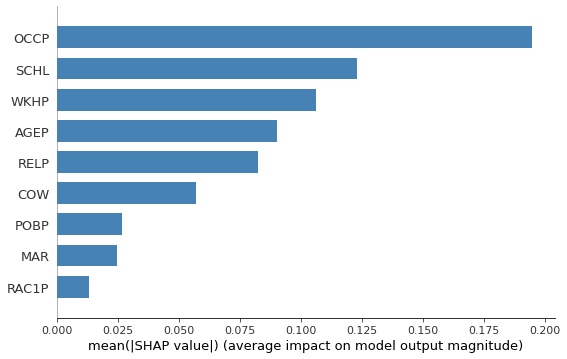

In [22]:
import shap

def group_shap_by_attribute(shap_values, columns):
    """Sum one-hot SHAP columns back to their original attribute """
    bases = ['AGEP','WKHP','COW','SCHL','MAR','OCCP','POBP','RELP','SEX','RAC1P']
    def base(c):
        return next((b for b in bases if c == b or c.startswith(b + '_')), c)
    sv = pd.DataFrame(shap_values, columns=list(columns)).T
    sv['attr'] = [base(c) for c in columns]
    agg = sv.groupby('attr').sum().T
    return agg.values, list(agg.columns)

def predict_adversarial(X_array):
    return mitigator.predict(X_array)

background_data = shap.sample(X_train_df.drop(columns=['SEX']), 100)
explainer = shap.KernelExplainer(predict_adversarial, background_data)

X_shap = X_test_df.drop(columns=['SEX'])[:10]
shap_values = explainer.shap_values(X_shap)

sv_agg, names = group_shap_by_attribute(shap_values, X_shap.columns)   # remap dummies -> attributes
shap.summary_plot(sv_agg, feature_names=names, plot_type="bar", color = "steelblue")

### Top features of the standard Logistic regression model using SHAP

X does not have valid feature names, but LogisticRegression was fitted with feature names


  0%|          | 0/10 [00:00<?, ?it/s]

X does not have valid feature names, but LogisticRegression was fitted with feature names
X does not have valid feature names, but LogisticRegression was fitted with feature names
X does not have valid feature names, but LogisticRegression was fitted with feature names
X does not have valid feature names, but LogisticRegression was fitted with feature names
X does not have valid feature names, but LogisticRegression was fitted with feature names
X does not have valid feature names, but LogisticRegression was fitted with feature names
X does not have valid feature names, but LogisticRegression was fitted with feature names
X does not have valid feature names, but LogisticRegression was fitted with feature names
X does not have valid feature names, but LogisticRegression was fitted with feature names
X does not have valid feature names, but LogisticRegression was fitted with feature names
X does not have valid feature names, but LogisticRegression was fitted with feature names
X does not

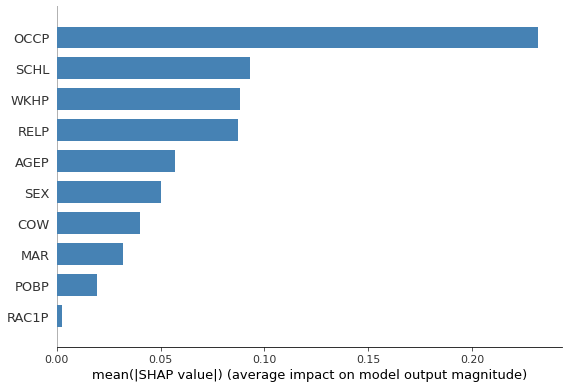

In [23]:
def predict_logreg1(X_array):
    return logreg1.predict(X_array)

background_data2 = shap.sample(X_train_df, 100)
explainer2 = shap.KernelExplainer(predict_logreg1, background_data2)

X_shap2 = X_test_df[:10]
shap_values2 = explainer2.shap_values(X_shap2)

sv_agg2, names2 = group_shap_by_attribute(shap_values2, X_shap2.columns)
shap.summary_plot(sv_agg2, feature_names=names2, plot_type="bar", color = "steelblue")

# Intersectional fairness analysis
### Per model subgroup tables

In [24]:
from IPython.display import display
models = {"full": y_pred1, "no_SEX": y_pred2, "no_proxies": y_pred3, "adversarial": y_pred4}

for name, yp in models.items():
    print(f"\n {name.upper()} ")
    display(intersectional_report(y_test, yp, sex_test, race_test, top_n_races=4).round(3))


 FULL 


,n,base_rate,selection_rate,accuracy,TPR,FPR,PPV,FDR,SPD,TPR_gap,FPR_gap,FDR_gap,acc_gap
Asian-Male,5046.0,0.514,0.539,0.815,0.845,0.216,0.805,0.195,0.046,0.044,0.017,-0.012,0.014
White-Male,32182.0,0.488,0.492,0.801,0.801,0.198,0.794,0.206,0.000,0.000,0.000,0.000,0.000
Asian-Female,4848.0,0.403,0.373,0.814,0.732,0.131,0.791,0.209,-0.119,-0.068,-0.068,0.003,0.013
Black-Male,3009.0,0.334,0.332,0.784,0.673,0.161,0.678,0.322,-0.160,-0.128,-0.038,0.116,-0.018
White-Female,28325.0,0.346,0.331,0.812,0.706,0.132,0.740,0.260,-0.162,-0.094,-0.067,0.054,0.011
Black-Female,3584.0,0.285,0.246,0.816,0.608,0.102,0.704,0.296,-0.246,-0.192,-0.096,0.090,0.014
Other-Male,3810.0,0.235,0.160,0.815,0.447,0.072,0.655,0.345,-0.332,-0.353,-0.126,0.139,0.014
Other-Female,3222.0,0.138,0.097,0.897,0.475,0.036,0.682,0.318,-0.396,-0.325,-0.163,0.112,0.095



 NO_SEX 


,n,base_rate,selection_rate,accuracy,TPR,FPR,PPV,FDR,SPD,TPR_gap,FPR_gap,FDR_gap,acc_gap
Asian-Male,5046.0,0.514,0.515,0.815,0.822,0.192,0.819,0.181,0.049,0.050,0.016,-0.012,0.017
White-Male,32182.0,0.488,0.467,0.799,0.772,0.176,0.807,0.193,0.000,0.000,0.000,0.000,0.000
Asian-Female,4848.0,0.403,0.407,0.818,0.779,0.155,0.772,0.228,-0.060,0.007,-0.021,0.035,0.020
White-Female,28325.0,0.346,0.362,0.809,0.746,0.158,0.714,0.286,-0.105,-0.026,-0.018,0.093,0.010
Black-Male,3009.0,0.334,0.304,0.792,0.643,0.134,0.707,0.293,-0.163,-0.129,-0.042,0.100,-0.007
Black-Female,3584.0,0.285,0.273,0.812,0.650,0.123,0.678,0.322,-0.193,-0.122,-0.053,0.129,0.014
Other-Male,3810.0,0.235,0.144,0.817,0.416,0.060,0.679,0.321,-0.323,-0.356,-0.116,0.128,0.018
Other-Female,3222.0,0.138,0.114,0.899,0.545,0.044,0.664,0.336,-0.353,-0.227,-0.132,0.143,0.100



 NO_PROXIES 


,n,base_rate,selection_rate,accuracy,TPR,FPR,PPV,FDR,SPD,TPR_gap,FPR_gap,FDR_gap,acc_gap
Asian-Male,5046.0,0.514,0.479,0.750,0.723,0.222,0.775,0.225,0.107,0.136,0.055,-0.004,0.036
Asian-Female,4848.0,0.403,0.462,0.720,0.726,0.284,0.633,0.367,0.090,0.138,0.118,0.138,0.006
White-Female,28325.0,0.346,0.409,0.733,0.705,0.253,0.596,0.404,0.037,0.117,0.086,0.174,0.019
White-Male,32182.0,0.488,0.372,0.714,0.588,0.166,0.771,0.229,0.000,0.000,0.000,0.000,0.000
Black-Female,3584.0,0.285,0.291,0.753,0.578,0.177,0.565,0.435,-0.081,-0.010,0.011,0.206,0.039
Black-Male,3009.0,0.334,0.236,0.731,0.450,0.128,0.638,0.362,-0.136,-0.137,-0.038,0.133,0.017
Other-Female,3222.0,0.138,0.094,0.877,0.397,0.045,0.584,0.416,-0.278,-0.191,-0.121,0.187,0.164
Other-Male,3810.0,0.235,0.059,0.784,0.166,0.026,0.658,0.342,-0.313,-0.422,-0.140,0.113,0.070



 ADVERSARIAL 


,n,base_rate,selection_rate,accuracy,TPR,FPR,PPV,FDR,SPD,TPR_gap,FPR_gap,FDR_gap,acc_gap
Asian-Male,5046.0,0.514,0.475,0.813,0.780,0.152,0.844,0.156,0.050,0.056,0.014,-0.011,0.018
White-Male,32182.0,0.488,0.425,0.795,0.725,0.139,0.833,0.167,0.000,0.000,0.000,0.000,0.000
Asian-Female,4848.0,0.403,0.413,0.815,0.782,0.163,0.764,0.236,-0.012,0.058,0.024,0.068,0.021
White-Female,28325.0,0.346,0.397,0.807,0.795,0.186,0.694,0.306,-0.028,0.071,0.047,0.139,0.013
Black-Female,3584.0,0.285,0.305,0.811,0.703,0.147,0.656,0.344,-0.119,-0.021,0.008,0.177,0.016
Black-Male,3009.0,0.334,0.268,0.780,0.572,0.116,0.713,0.287,-0.156,-0.153,-0.023,0.120,-0.015
Other-Female,3222.0,0.138,0.110,0.898,0.531,0.043,0.666,0.334,-0.314,-0.193,-0.096,0.167,0.104
Other-Male,3810.0,0.235,0.094,0.812,0.299,0.031,0.746,0.254,-0.331,-0.426,-0.107,0.087,0.017


### Single axis vs Intersectional


In [25]:
summary = pd.DataFrame([
    disparity_summary(y_test, yp, sex_test, race_test, model_name=name)
    for name, yp in models.items()
])
display(summary.round(4))


,model,sex_only_SPD,race_only_SPD,intersectional_SPD,worst_subgroup,best_subgroup
0,full,0.1467,0.3264,0.4421,Other-Female,Asian-Male
1,no_SEX,0.0923,0.3322,0.4019,Other-Female,Asian-Male
2,no_proxies,0.0320,0.3958,0.4203,Other-Male,Asian-Male
3,adversarial,0.0225,0.3428,0.3809,Other-Male,Asian-Male


### SPD per subgroup across models


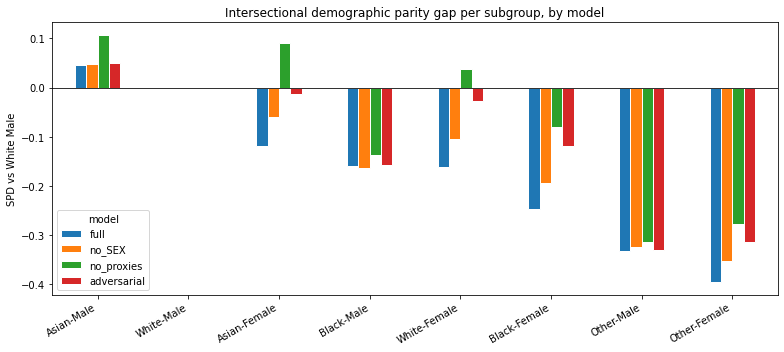

In [26]:
import matplotlib.pyplot as plt
spd_tab = pd.DataFrame({
    name: intersectional_report(y_test, yp, sex_test, race_test, top_n_races=4)["SPD"]
    for name, yp in models.items()})
spd_tab = spd_tab.sort_values("full", ascending=False)
spd_tab.plot(kind="bar", figsize=(11,5), edgecolor="white")

plt.axhline(0, color="black", lw=0.8)
plt.ylabel("SPD vs White Male"); plt.title("Intersectional demographic parity gap per subgroup, by model")
plt.xticks(rotation=30, ha="right"); plt.legend(title="model"); plt.tight_layout(); plt.show()

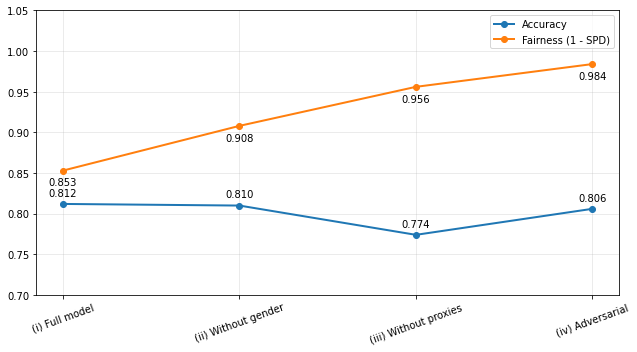

In [27]:
df = pd.DataFrame({
    "Model": [
        "(i) Full model",
        "(ii) Without gender",
        "(iii) Without proxies",
        "(iv) Adversarial"
    ],
    "Accuracy": [0.812, 0.810, 0.774, 0.806],
    "SPD": [0.147, 0.092, 0.044, 0.016]
})

df["Fairness Score"] = 1 - df["SPD"]

plt.figure(figsize=(9,5))

# Accuracy
plt.plot(
    df["Model"],
    df["Accuracy"],
    marker="o",
    linewidth=2,
    label="Accuracy"
)

# Fairness (1-SPD)
plt.plot(
    df["Model"],
    df["Fairness Score"],
    marker="o",
    linewidth=2,
    label="Fairness (1 - SPD)"
)

for i, row in df.iterrows():
    plt.annotate(f"{row['Accuracy']:.3f}",
                 (row["Model"], row["Accuracy"]),
                 xytext=(0,8),
                 textcoords="offset points",
                 ha="center")

    plt.annotate(f"{row['Fairness Score']:.3f}",
                 (row["Model"], row["Fairness Score"]),
                 xytext=(0,-15),
                 textcoords="offset points",
                 ha="center")

#plt.ylabel("Score (higher = better)")
#plt.title("Fairness–Accuracy Trade-off")
plt.ylim(0.7, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

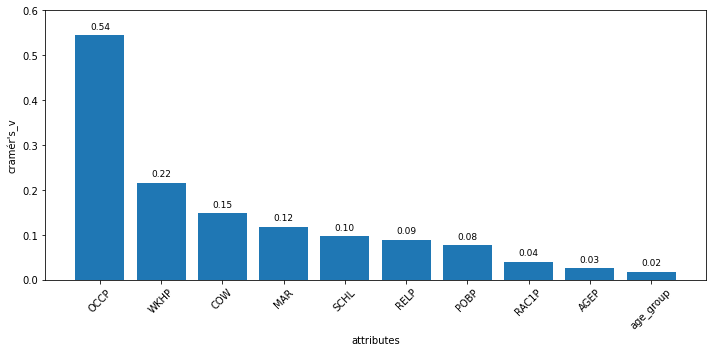

In [28]:
data = {
    "feature": ["OCCP", "WKHP", "COW", "MAR",
                "SCHL", "RELP", "POBP", "RAC1P", "AGEP", "age_group"],
    "cramers_v": [0.544436, 0.215601, 0.148008, 0.117763,
                  0.096538, 0.088253, 0.076341, 0.039927, 0.025396, 0.017253]
}

df = pd.DataFrame(data).sort_values("cramers_v", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df["feature"], df["cramers_v"])

ax.set_xlabel("attributes")
ax.set_ylabel("cramér's_v")
#ax.set_title("Feature Association with Sex")
ax.set_ylim(0, 0.6)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

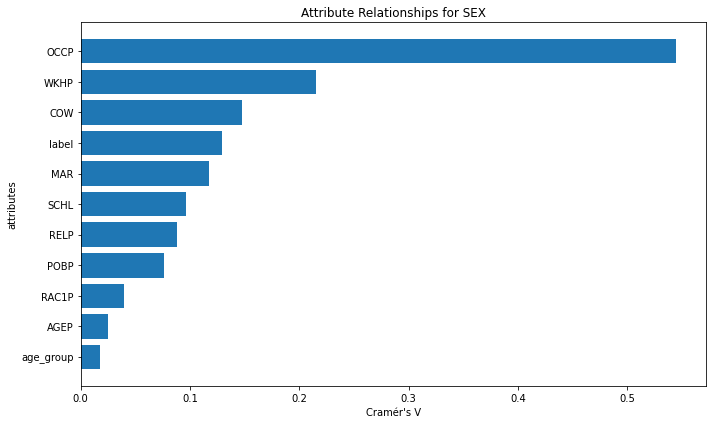

In [29]:
# UNUSED IN THE PAPER
data = {
    "feature": ["OCCP","WKHP","COW","label","MAR","SCHL","RELP","POBP","RAC1P","AGEP","age_group"],
    "cramers_v": [0.544436,0.215601,0.148008,0.129354,0.117763,
                  0.096538,0.088253,0.076341,0.039927,0.025396,0.017253]
}

df = pd.DataFrame(data)
df = df.sort_values("cramers_v", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(df["feature"], df["cramers_v"])

plt.xlabel("Cramér's V")
plt.ylabel("attributes")
plt.title("Attribute Relationships for SEX")
plt.tight_layout()

plt.show()

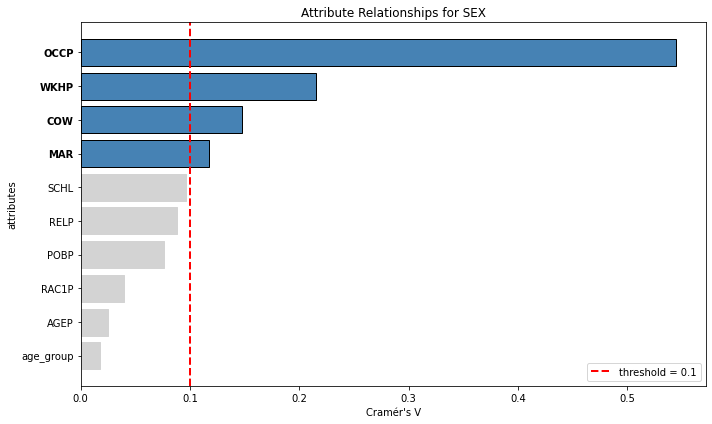

In [30]:
df_plot = df[df["feature"] != "label"].copy()
df_plot = df_plot.sort_values("cramers_v", ascending=True)

threshold = 0.1
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_plot["feature"], df_plot["cramers_v"])

#threshold
ax.axvline(x=threshold, color="red", linestyle="--", linewidth=2,
            label="threshold = 0.1")

for bar, value, label in zip(bars, df_plot["cramers_v"], df_plot["feature"]):
    if value > threshold:
        # Thicher script for y-axis labels
        bar.set_color("steelblue")
        bar.set_edgecolor("black")
    else:
        bar.set_color("lightgray")

for tick_label, value in zip(ax.get_yticklabels(), df_plot["cramers_v"]):
    if value > threshold:
        tick_label.set_fontweight("bold")

ax.set_xlabel("Cramér's V")
ax.set_ylabel("attributes")
ax.set_title("Attribute Relationships for SEX")
ax.legend()

plt.tight_layout()
plt.show()

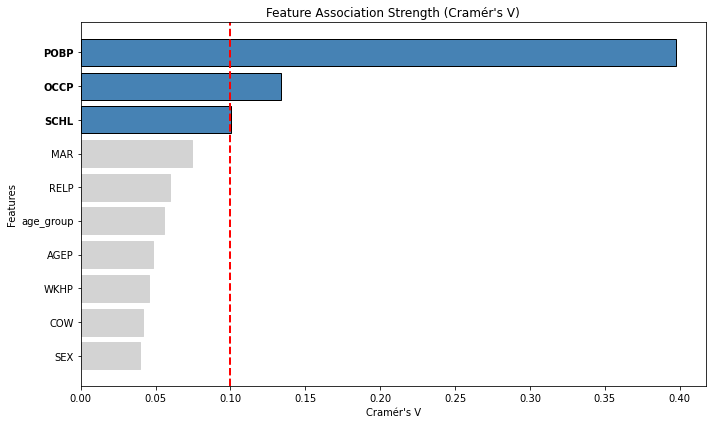

In [31]:
data = {
    "feature": ["POBP","label","OCCP","SCHL","MAR","RELP","age_group","AGEP","WKHP","COW","SEX"],
    "cramers_v": [0.397471,0.146903,0.133933,0.100529,0.074297,
                  0.059775,0.055861,0.048429,0.045395,0.041697,0.039927]
}

df = pd.DataFrame(data)
df = df[df["feature"] != "label"]
df = df.sort_values("cramers_v", ascending=True)

threshold = 0.1

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df["feature"], df["cramers_v"])
ax.axvline(x=threshold, color="red", linestyle="--", linewidth=2)

# Styling: Colours + thick labels
for bar, val in zip(bars, df["cramers_v"]):
    if val > threshold:
        bar.set_color("steelblue")
        bar.set_edgecolor("black")
    else:
        bar.set_color("lightgray")

for tick_label, val in zip(ax.get_yticklabels(), df["cramers_v"]):
    if val > threshold:
        tick_label.set_fontweight("bold")

ax.set_xlabel("Cramér's V")
ax.set_ylabel("Features")
ax.set_title("Feature Association Strength (Cramér's V)")

plt.tight_layout()
plt.show()